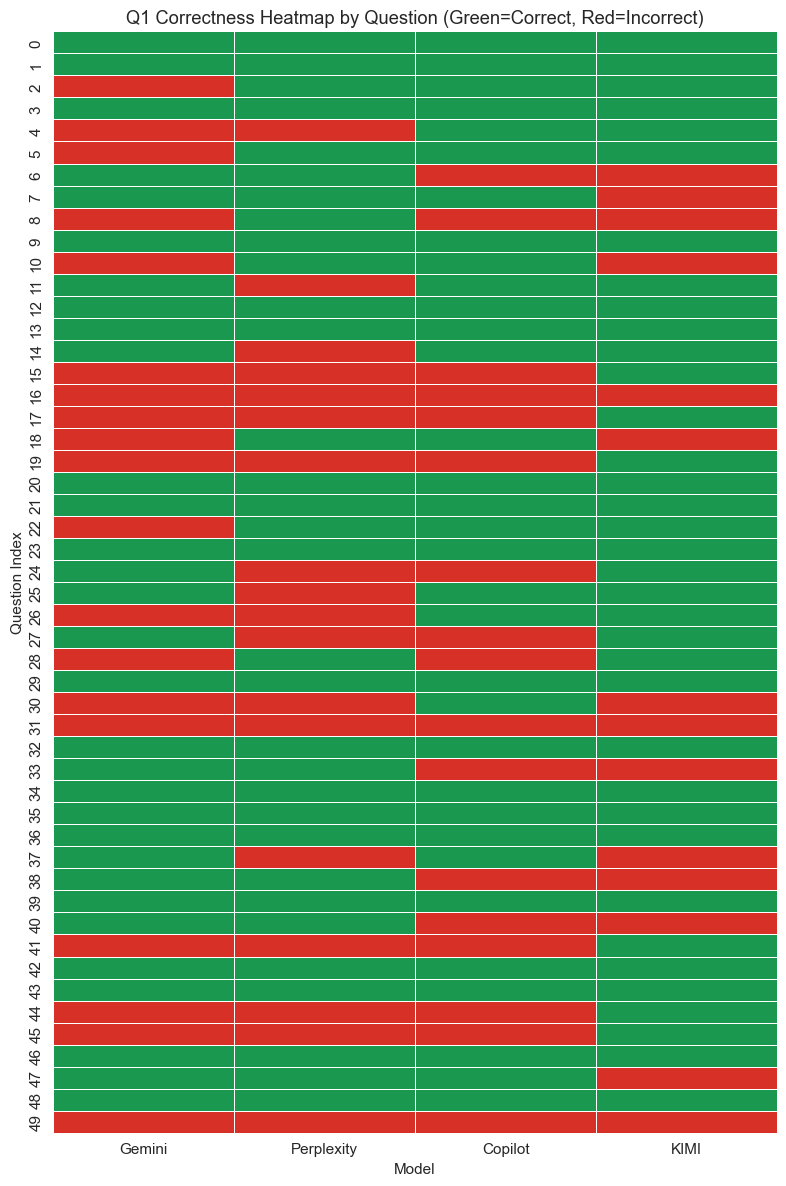

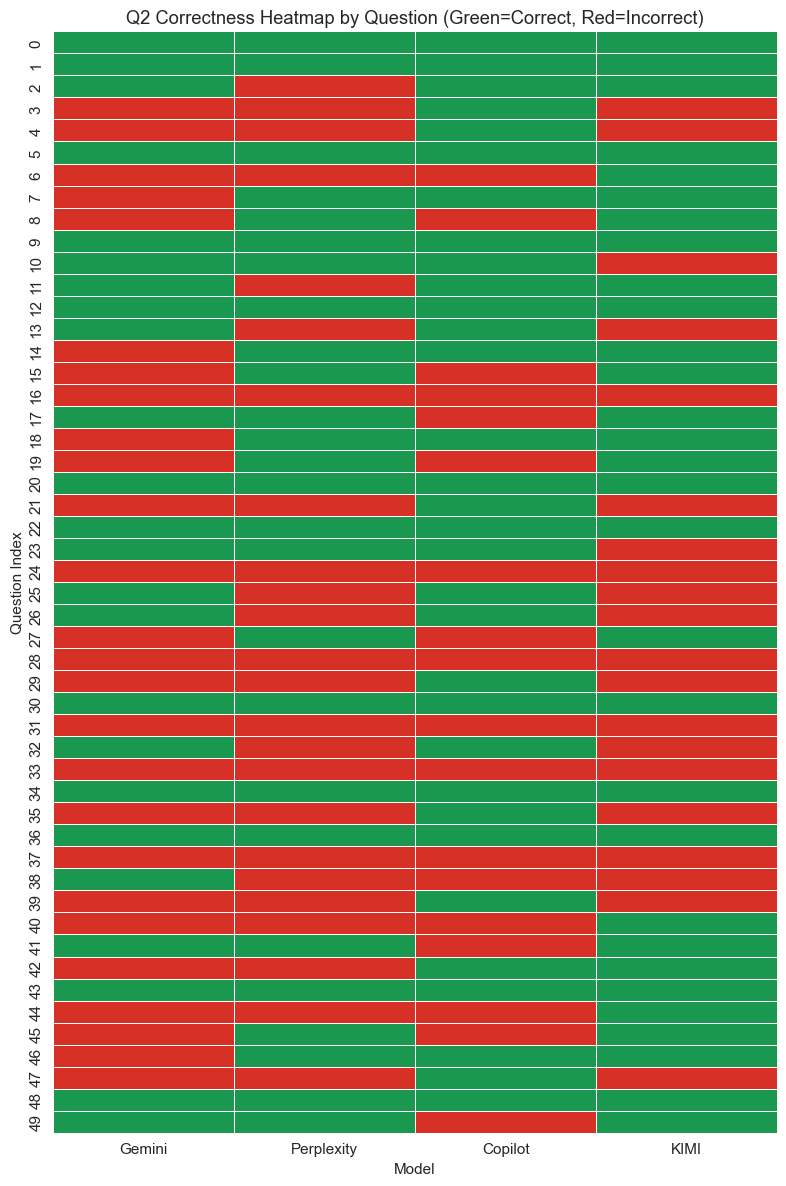

C:\Users\user\AppData\Local\Temp\ipykernel_17012\843873060.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=q1, x="num_models_correct", palette="Blues")


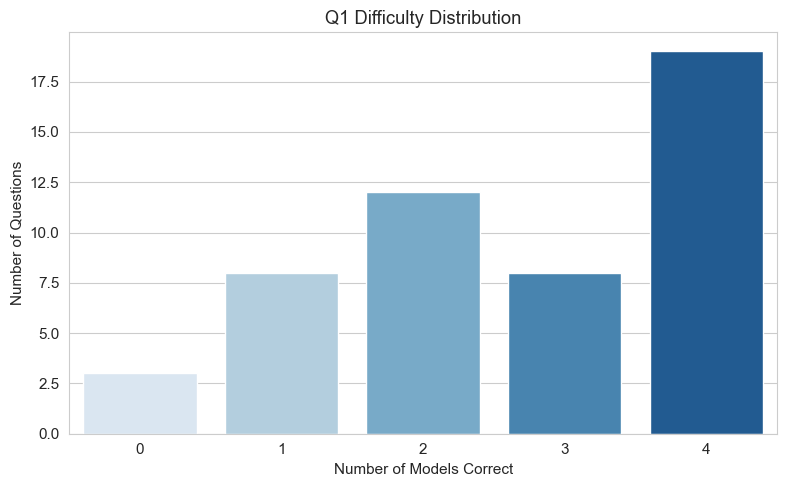

C:\Users\user\AppData\Local\Temp\ipykernel_17012\843873060.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=q2, x="num_models_correct", palette="Purples")


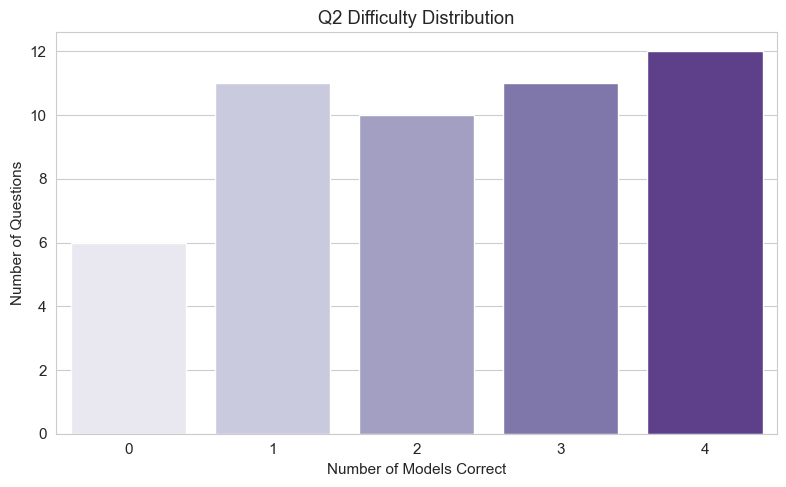

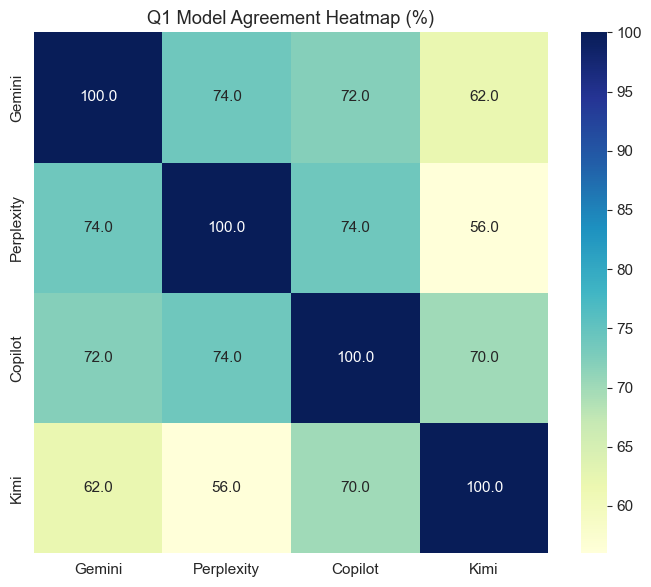

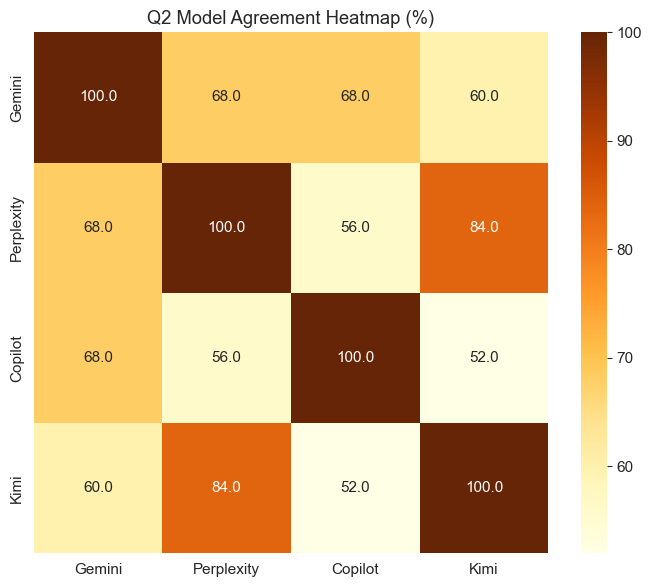

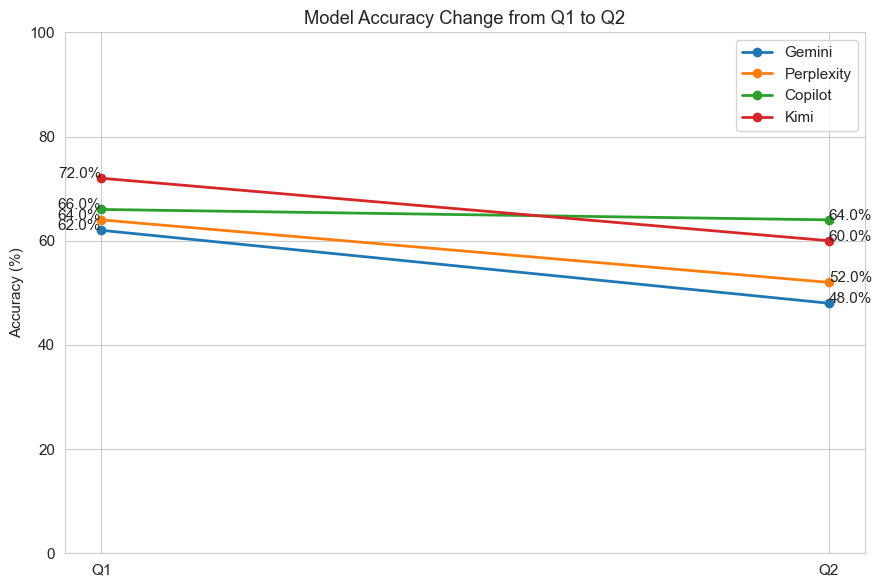

C:\Users\user\AppData\Local\Temp\ipykernel_17012\843873060.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=diff_df, x="Model", y="Change", palette=colors)


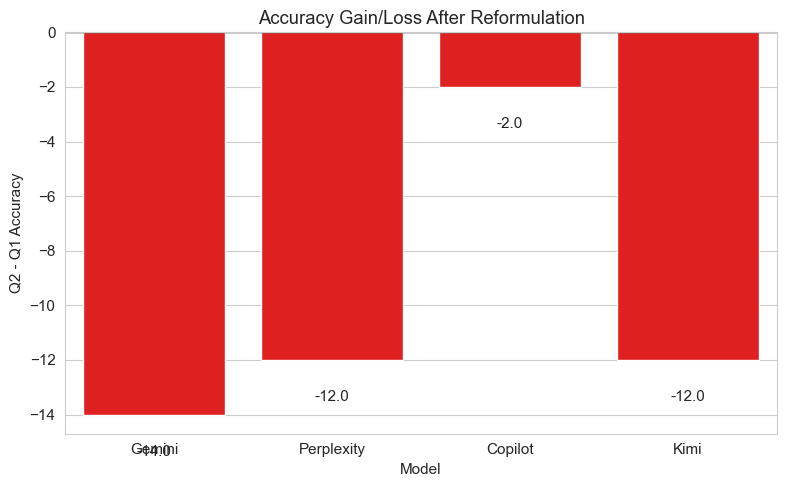

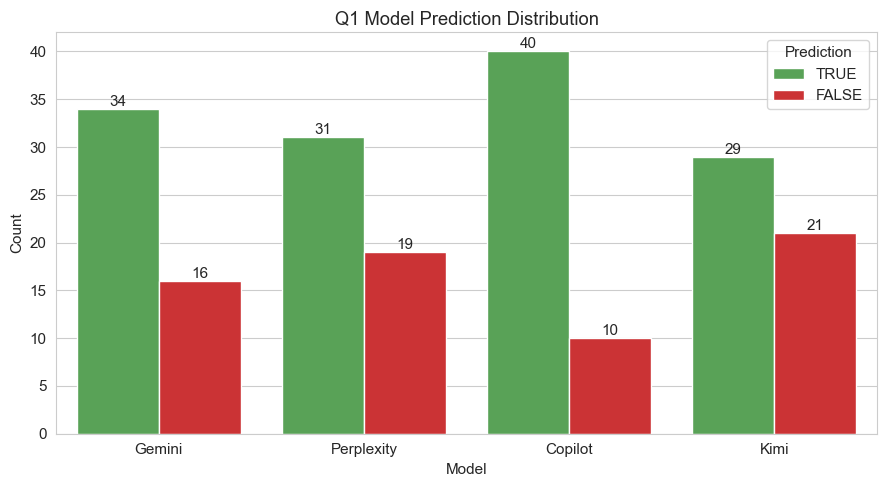

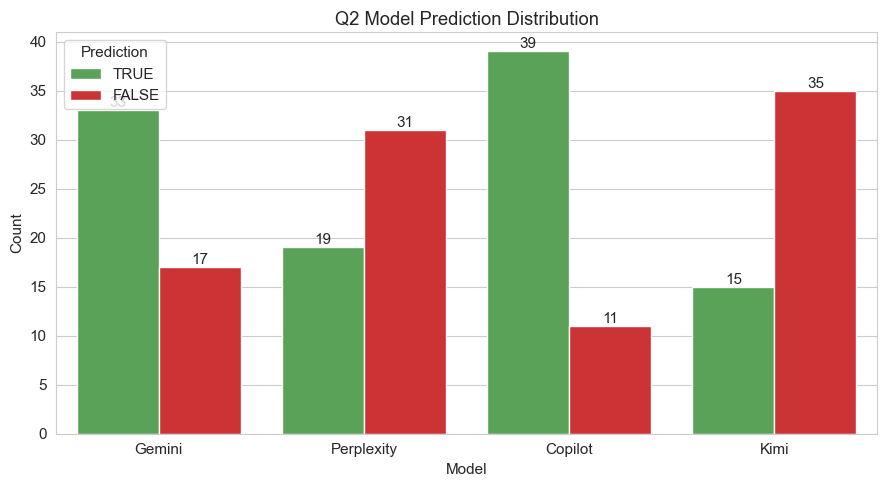

Top 10 hardest Q1 questions:


,question,answer,num_models_correct
49,IN THE WAKE OF RACIAL JUSTICE PROTESTS ACROSS ...,FAKE,0
31,SEARCH THE OFFICIAL ARCHIVES OF THE BULGARIAN ...,REAL,0
16,"DURING A MEETING WITH RUSSIA'S PRIME MINISTER,...",FAKE,0
15,ONE OF THE LARGEST MULTINATIONAL MILITARY EXER...,FAKE,1
19,A POLITICAL ANALYSIS PUBLISHED IN WESTERN EURO...,FAKE,1
30,NEWS FROM HIGHLY ACTIVE SEISMIC ZONES IS OFTEN...,REAL,1
8,IS THE PORTRAYAL OF EU LEADERS' ACTIONS AND PO...,FAKE,1
41,THE SYRIAN ARMY CONDUCTED OPERATIONS IN ALEPPO...,FAKE,1
44,DIFFERENT INVESTIGATIONS AND OFFICIALS HAVE RE...,FAKE,1
45,ZAKHAROVA LINKS SANCTIONS AGAINST RUSSIA TO IN...,FAKE,1


Top 10 hardest Q2 questions:


,question,answer,num_models_correct
24,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, LAT...",FAKE,0
31,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, TOD...",REAL,0
33,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, TAY...",REAL,0
37,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, SLA...",REAL,0
16,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, ALE...",FAKE,0
28,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, THE...",FAKE,0
6,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, NAS...",FAKE,1
29,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, TUR...",REAL,1
47,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, INV...",REAL,1
21,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, THE...",REAL,1


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# -----------------------------
# 1. Load files
# -----------------------------
q1 = pd.read_excel("C:/Users/user/Downloads/q1.xlsx")
q2 = pd.read_excel("C:/Users/user/Downloads/q2.xlsx")

q1.columns = ["news", "question", "answer", "gemini", "perplexity", "copilot", "kimi"]
q2.columns = ["news", "answer", "question", "gemini", "perplexity", "copilot", "kimi"]

for df in [q1, q2]:
    for col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

truth_map = {"REAL": "TRUE", "FAKE": "FALSE"}
q1["expected"] = q1["answer"].map(truth_map)
q2["expected"] = q2["answer"].map(truth_map)

models = ["gemini", "perplexity", "copilot", "kimi"]

# correctness matrices
for model in models:
    q1[f"{model}_correct"] = (q1[model] == q1["expected"]).astype(int)
    q2[f"{model}_correct"] = (q2[model] == q2["expected"]).astype(int)

# -----------------------------
# 2. Correctness heatmap by question
# -----------------------------
q1_heat = q1[[f"{m}_correct" for m in models]].copy()
q1_heat.columns = ["Gemini", "Perplexity", "Copilot", "KIMI"]

plt.figure(figsize=(8, 12))
sns.heatmap(q1_heat, cmap=["#d73027", "#1a9850"], cbar=False, linewidths=0.5, linecolor="white")
plt.title("Q1 Correctness Heatmap by Question (Green=Correct, Red=Incorrect)")
plt.xlabel("Model")
plt.ylabel("Question Index")
plt.tight_layout()
plt.show()

q2_heat = q2[[f"{m}_correct" for m in models]].copy()
q2_heat.columns = ["Gemini", "Perplexity", "Copilot", "KIMI"]

plt.figure(figsize=(8, 12))
sns.heatmap(q2_heat, cmap=["#d73027", "#1a9850"], cbar=False, linewidths=0.5, linecolor="white")
plt.title("Q2 Correctness Heatmap by Question (Green=Correct, Red=Incorrect)")
plt.xlabel("Model")
plt.ylabel("Question Index")
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Difficulty distribution
#    How many models got each question correct?
# -----------------------------
q1["num_models_correct"] = q1[[f"{m}_correct" for m in models]].sum(axis=1)
q2["num_models_correct"] = q2[[f"{m}_correct" for m in models]].sum(axis=1)

plt.figure(figsize=(8, 5))
sns.countplot(data=q1, x="num_models_correct", palette="Blues")
plt.title("Q1 Difficulty Distribution")
plt.xlabel("Number of Models Correct")
plt.ylabel("Number of Questions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=q2, x="num_models_correct", palette="Purples")
plt.title("Q2 Difficulty Distribution")
plt.xlabel("Number of Models Correct")
plt.ylabel("Number of Questions")
plt.tight_layout()
plt.show()

# -----------------------------
# 4. Agreement heatmap
#    How often models gave same raw answer
# -----------------------------
def agreement_matrix(df, models):
    mat = pd.DataFrame(index=[m.capitalize() for m in models], columns=[m.capitalize() for m in models], dtype=float)
    for m1 in models:
        for m2 in models:
            mat.loc[m1.capitalize(), m2.capitalize()] = (df[m1] == df[m2]).mean() * 100
    return mat

q1_agree = agreement_matrix(q1, models)
q2_agree = agreement_matrix(q2, models)

plt.figure(figsize=(7, 6))
sns.heatmap(q1_agree, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Q1 Model Agreement Heatmap (%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
sns.heatmap(q2_agree, annot=True, fmt=".1f", cmap="YlOrBr")
plt.title("Q2 Model Agreement Heatmap (%)")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Q1 vs Q2 slope chart
# -----------------------------
acc_q1 = {m.capitalize(): q1[f"{m}_correct"].mean() * 100 for m in models}
acc_q2 = {m.capitalize(): q2[f"{m}_correct"].mean() * 100 for m in models}

plt.figure(figsize=(9, 6))
for model in acc_q1.keys():
    plt.plot(["Q1", "Q2"], [acc_q1[model], acc_q2[model]], marker="o", linewidth=2, label=model)

for model in acc_q1.keys():
    plt.text("Q1", acc_q1[model], f"{acc_q1[model]:.1f}%", ha="right")
    plt.text("Q2", acc_q2[model], f"{acc_q2[model]:.1f}%", ha="left")

plt.title("Model Accuracy Change from Q1 to Q2")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Improvement / decline bar chart
# -----------------------------
diff_df = pd.DataFrame({
    "Model": list(acc_q1.keys()),
    "Q1 Accuracy": list(acc_q1.values()),
    "Q2 Accuracy": list(acc_q2.values())
})
diff_df["Change"] = diff_df["Q2 Accuracy"] - diff_df["Q1 Accuracy"]

plt.figure(figsize=(8, 5))
colors = ["green" if x >= 0 else "red" for x in diff_df["Change"]]
ax = sns.barplot(data=diff_df, x="Model", y="Change", palette=colors)
plt.axhline(0, color="black", linewidth=1)
plt.title("Accuracy Gain/Loss After Reformulation")
plt.ylabel("Q2 - Q1 Accuracy")
for i, v in enumerate(diff_df["Change"]):
    ax.text(i, v + (0.5 if v >= 0 else -1.5), f"{v:.1f}", ha="center")
plt.tight_layout()
plt.show()

# -----------------------------
# 7. Real vs Fake answer balance by model
#    What each model tends to predict
# -----------------------------
def prediction_distribution(df, title, palette):
    pred_rows = []
    for model in models:
        counts = df[model].value_counts(dropna=False)
        for ans in ["TRUE", "FALSE"]:
            pred_rows.append({
                "Model": model.capitalize(),
                "Prediction": ans,
                "Count": counts.get(ans, 0)
            })
    pred_df = pd.DataFrame(pred_rows)

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(data=pred_df, x="Model", y="Count", hue="Prediction", palette=palette)
    plt.title(title)
    for container in ax.containers:
        ax.bar_label(container)
    plt.tight_layout()
    plt.show()

prediction_distribution(q1, "Q1 Model Prediction Distribution", ["#4daf4a", "#e41a1c"])
prediction_distribution(q2, "Q2 Model Prediction Distribution", ["#4daf4a", "#e41a1c"])

# -----------------------------
# 8. Hardest questions
#    Questions missed by most models
# -----------------------------
hard_q1 = q1[["question", "answer", "num_models_correct"]].sort_values("num_models_correct").head(10)
hard_q2 = q2[["question", "answer", "num_models_correct"]].sort_values("num_models_correct").head(10)

print("Top 10 hardest Q1 questions:")
display(hard_q1)

print("Top 10 hardest Q2 questions:")
display(hard_q2)

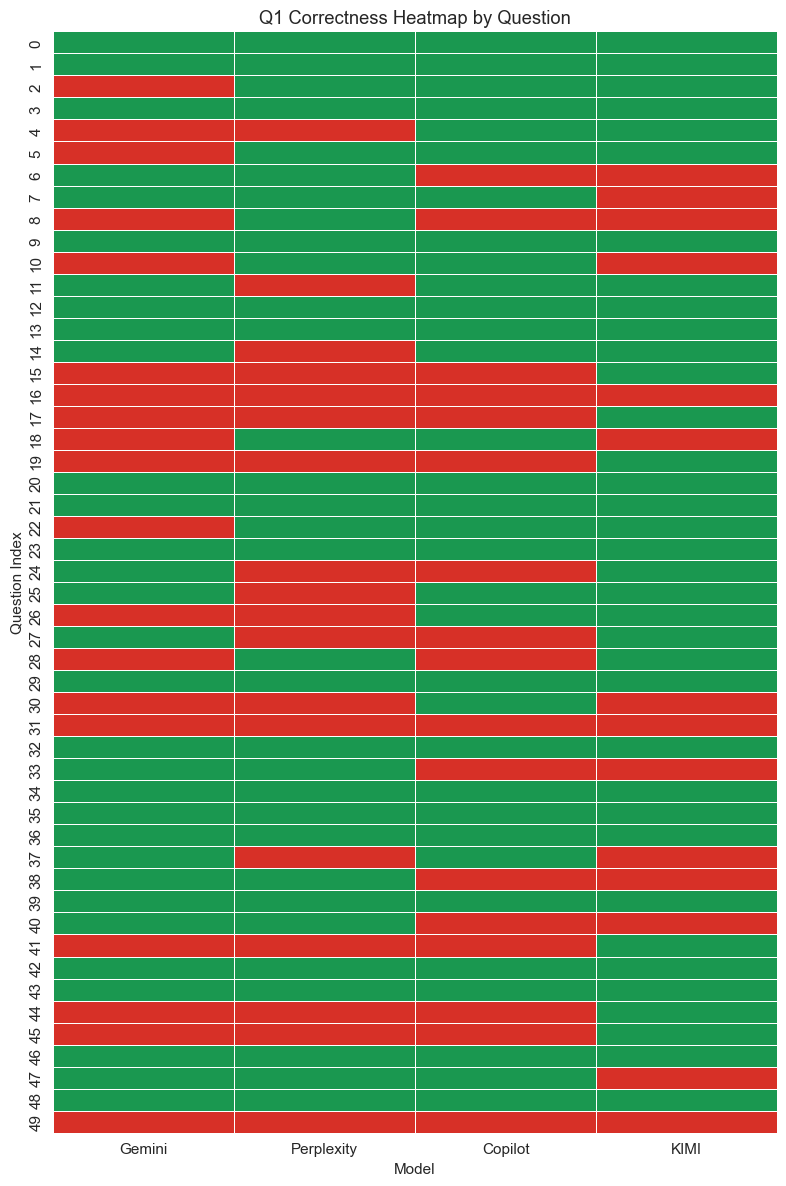

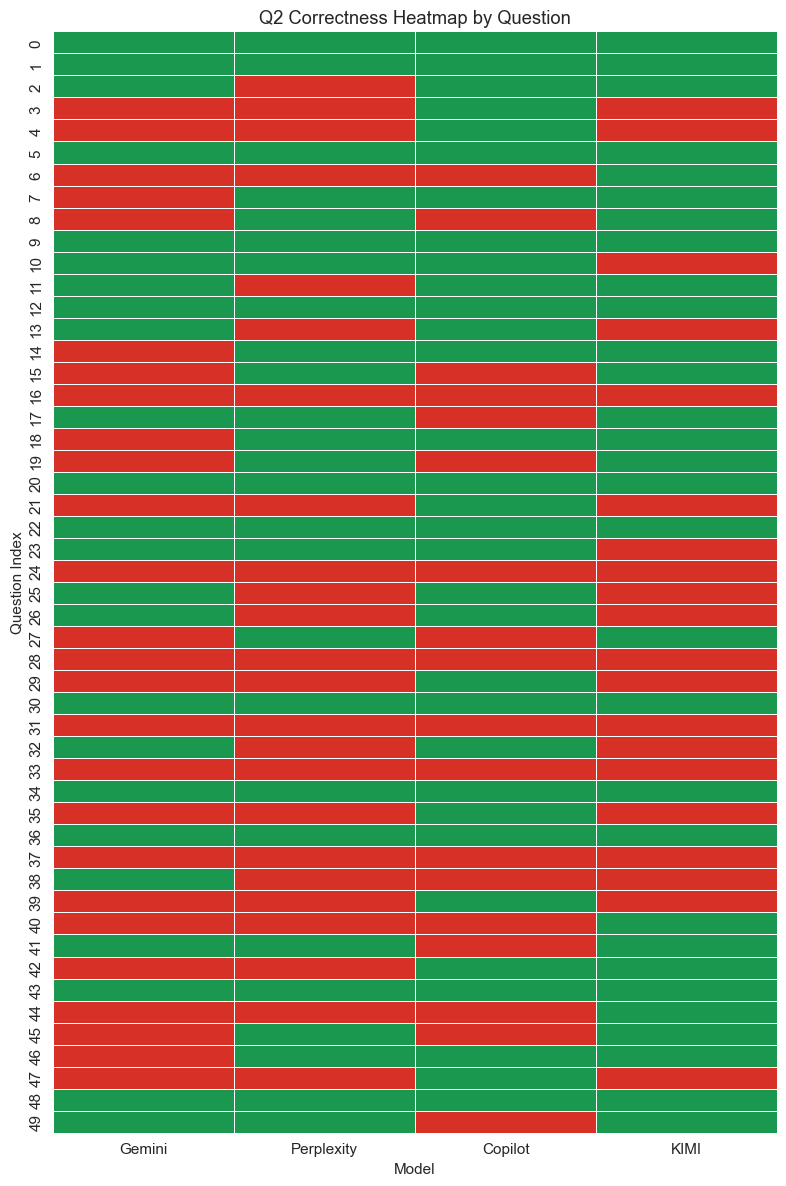

C:\Users\user\AppData\Local\Temp\ipykernel_17012\2692832096.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=q1, x="num_models_correct", palette="Blues")


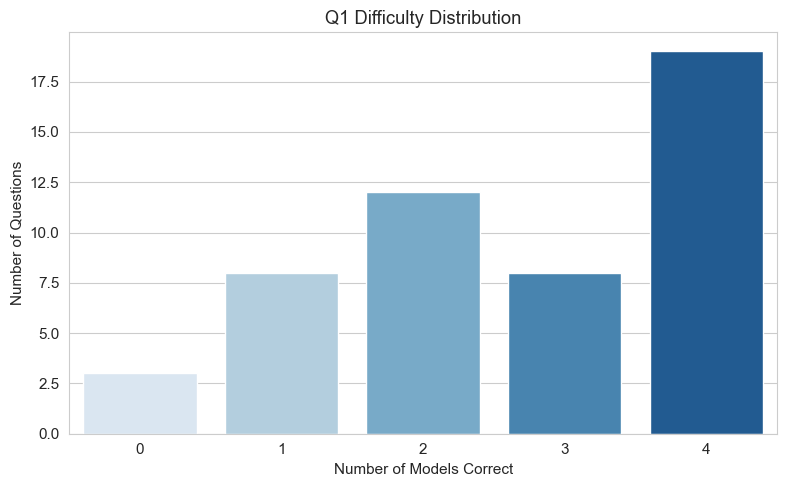

C:\Users\user\AppData\Local\Temp\ipykernel_17012\2692832096.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=q2, x="num_models_correct", palette="Purples")


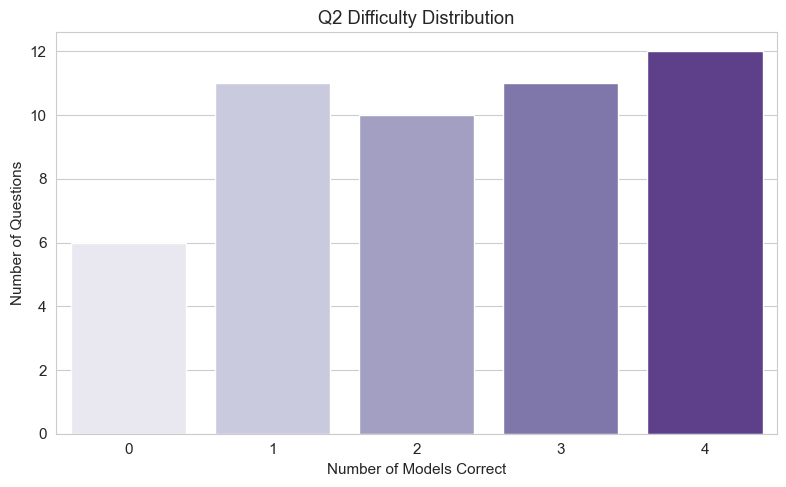

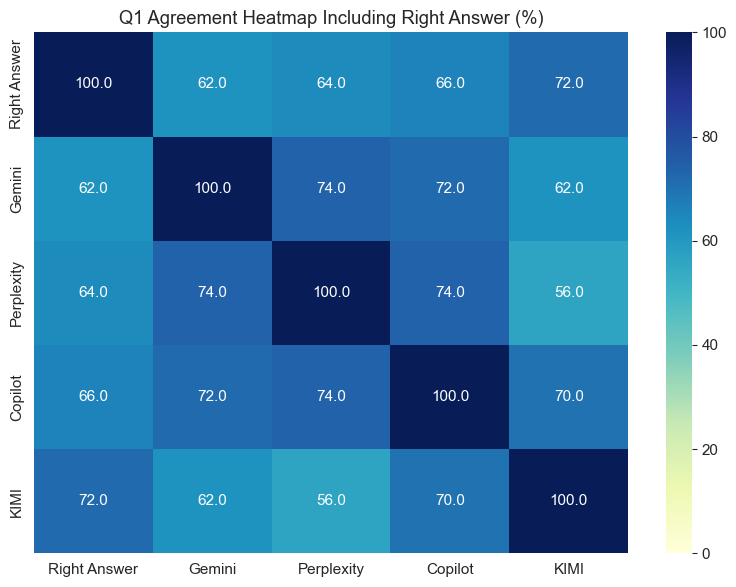

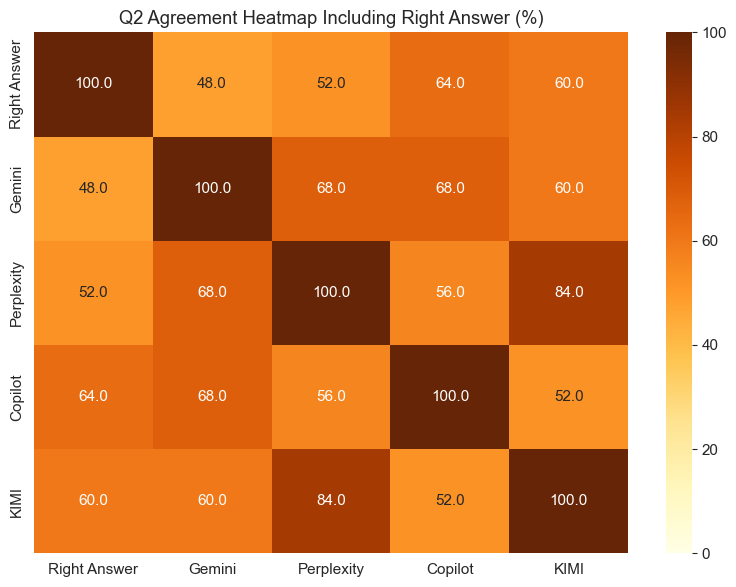

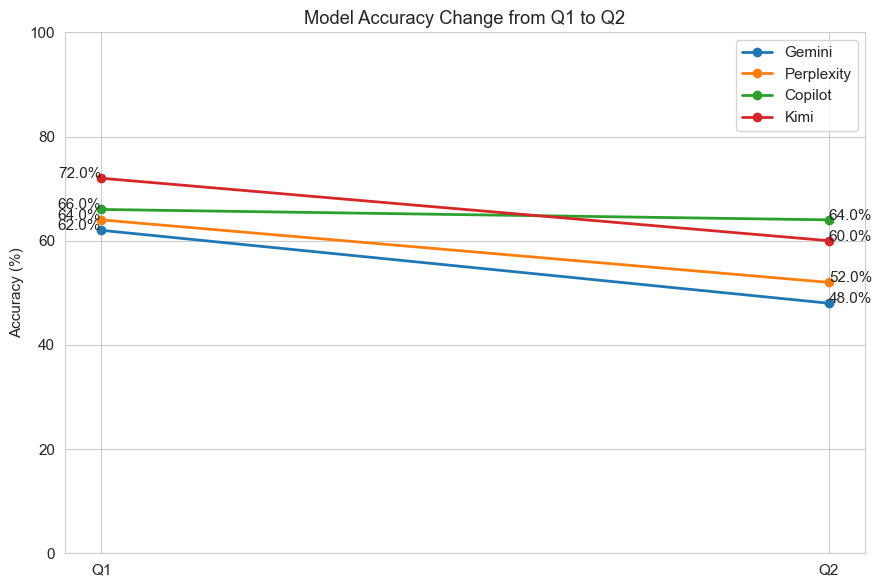

C:\Users\user\AppData\Local\Temp\ipykernel_17012\2692832096.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=diff_df, x="Model", y="Change", palette=colors)


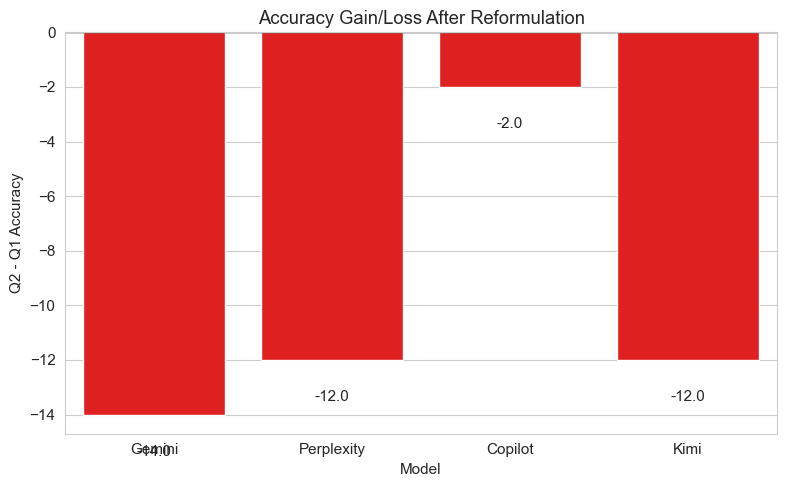

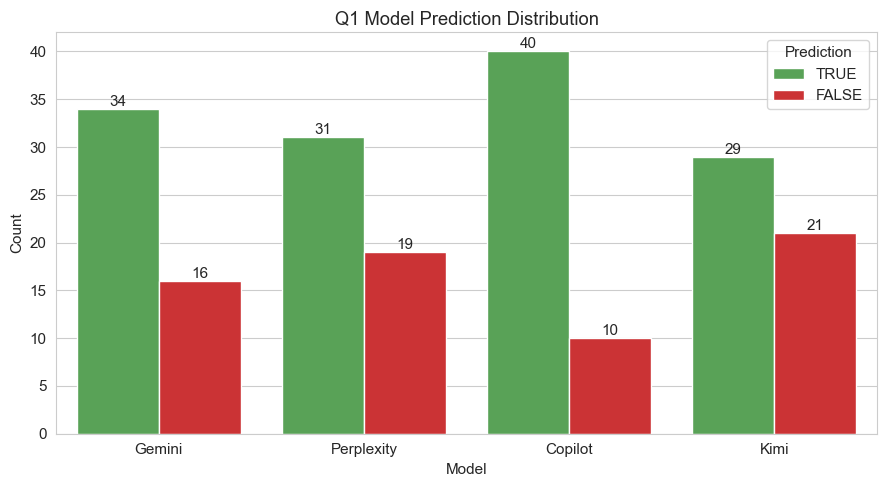

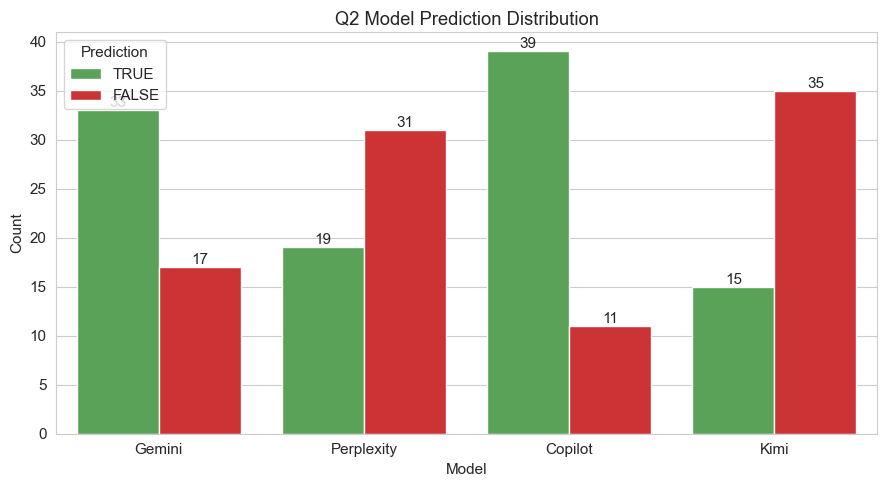

All graphs saved in folder: saved_graphs


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# -----------------------------------
# 1. Make folder for saved figures
# -----------------------------------
save_dir = "saved_graphs"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------------
# 2. Load files
# -----------------------------------
q1 = pd.read_excel("C:/Users/user/Downloads/q1.xlsx")
q2 = pd.read_excel("C:/Users/user/Downloads/q2.xlsx")

q1.columns = ["news", "question", "answer", "gemini", "perplexity", "copilot", "kimi"]
q2.columns = ["news", "answer", "question", "gemini", "perplexity", "copilot", "kimi"]

for df in [q1, q2]:
    for col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

truth_map = {"REAL": "TRUE", "FAKE": "FALSE"}
q1["expected"] = q1["answer"].map(truth_map)
q2["expected"] = q2["answer"].map(truth_map)

models = ["gemini", "perplexity", "copilot", "kimi"]

for model in models:
    q1[f"{model}_correct"] = (q1[model] == q1["expected"]).astype(int)
    q2[f"{model}_correct"] = (q2[model] == q2["expected"]).astype(int)

# -----------------------------------
# Helper function to save and show
# -----------------------------------
def save_and_show(filename):
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------------
# 3. Correctness heatmaps
# -----------------------------------
q1_heat = q1[[f"{m}_correct" for m in models]].copy()
q1_heat.columns = ["Gemini", "Perplexity", "Copilot", "KIMI"]

plt.figure(figsize=(8, 12))
sns.heatmap(q1_heat, cmap=["#d73027", "#1a9850"], cbar=False, linewidths=0.5, linecolor="white")
plt.title("Q1 Correctness Heatmap by Question")
plt.xlabel("Model")
plt.ylabel("Question Index")
save_and_show("q1_correctness_heatmap.png")

q2_heat = q2[[f"{m}_correct" for m in models]].copy()
q2_heat.columns = ["Gemini", "Perplexity", "Copilot", "KIMI"]

plt.figure(figsize=(8, 12))
sns.heatmap(q2_heat, cmap=["#d73027", "#1a9850"], cbar=False, linewidths=0.5, linecolor="white")
plt.title("Q2 Correctness Heatmap by Question")
plt.xlabel("Model")
plt.ylabel("Question Index")
save_and_show("q2_correctness_heatmap.png")

# -----------------------------------
# 4. Difficulty distributions
# -----------------------------------
q1["num_models_correct"] = q1[[f"{m}_correct" for m in models]].sum(axis=1)
q2["num_models_correct"] = q2[[f"{m}_correct" for m in models]].sum(axis=1)

plt.figure(figsize=(8, 5))
sns.countplot(data=q1, x="num_models_correct", palette="Blues")
plt.title("Q1 Difficulty Distribution")
plt.xlabel("Number of Models Correct")
plt.ylabel("Number of Questions")
save_and_show("q1_difficulty_distribution.png")

plt.figure(figsize=(8, 5))
sns.countplot(data=q2, x="num_models_correct", palette="Purples")
plt.title("Q2 Difficulty Distribution")
plt.xlabel("Number of Models Correct")
plt.ylabel("Number of Questions")
save_and_show("q2_difficulty_distribution.png")

# -----------------------------------
# 5. Agreement heatmap INCLUDING right answer
# -----------------------------------
def agreement_with_truth(df):
    compare_cols = ["expected", "gemini", "perplexity", "copilot", "kimi"]
    display_names = {
        "expected": "Right Answer",
        "gemini": "Gemini",
        "perplexity": "Perplexity",
        "copilot": "Copilot",
        "kimi": "KIMI"
    }

    mat = pd.DataFrame(index=[display_names[c] for c in compare_cols],
                       columns=[display_names[c] for c in compare_cols],
                       dtype=float)

    for c1 in compare_cols:
        for c2 in compare_cols:
            mat.loc[display_names[c1], display_names[c2]] = (df[c1] == df[c2]).mean() * 100

    return mat

q1_agree_truth = agreement_with_truth(q1)
q2_agree_truth = agreement_with_truth(q2)

plt.figure(figsize=(8, 6))
sns.heatmap(q1_agree_truth, annot=True, fmt=".1f", cmap="YlGnBu", vmin=0, vmax=100)
plt.title("Q1 Agreement Heatmap Including Right Answer (%)")
save_and_show("q1_agreement_with_truth_heatmap.png")

plt.figure(figsize=(8, 6))
sns.heatmap(q2_agree_truth, annot=True, fmt=".1f", cmap="YlOrBr", vmin=0, vmax=100)
plt.title("Q2 Agreement Heatmap Including Right Answer (%)")
save_and_show("q2_agreement_with_truth_heatmap.png")

# -----------------------------------
# 6. Accuracy slope chart
# -----------------------------------
acc_q1 = {m.capitalize(): q1[f"{m}_correct"].mean() * 100 for m in models}
acc_q2 = {m.capitalize(): q2[f"{m}_correct"].mean() * 100 for m in models}

plt.figure(figsize=(9, 6))
for model in acc_q1.keys():
    plt.plot(["Q1", "Q2"], [acc_q1[model], acc_q2[model]], marker="o", linewidth=2, label=model)

for model in acc_q1.keys():
    plt.text("Q1", acc_q1[model], f"{acc_q1[model]:.1f}%", ha="right")
    plt.text("Q2", acc_q2[model], f"{acc_q2[model]:.1f}%", ha="left")

plt.title("Model Accuracy Change from Q1 to Q2")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.legend()
save_and_show("q1_q2_accuracy_slope.png")

# -----------------------------------
# 7. Gain / loss chart
# -----------------------------------
diff_df = pd.DataFrame({
    "Model": list(acc_q1.keys()),
    "Q1 Accuracy": list(acc_q1.values()),
    "Q2 Accuracy": list(acc_q2.values())
})
diff_df["Change"] = diff_df["Q2 Accuracy"] - diff_df["Q1 Accuracy"]

plt.figure(figsize=(8, 5))
colors = ["green" if x >= 0 else "red" for x in diff_df["Change"]]
ax = sns.barplot(data=diff_df, x="Model", y="Change", palette=colors)
plt.axhline(0, color="black", linewidth=1)
plt.title("Accuracy Gain/Loss After Reformulation")
plt.ylabel("Q2 - Q1 Accuracy")
for i, v in enumerate(diff_df["Change"]):
    ax.text(i, v + (0.5 if v >= 0 else -1.5), f"{v:.1f}", ha="center")
save_and_show("q1_q2_gain_loss.png")

# -----------------------------------
# 8. Prediction distribution
# -----------------------------------
def prediction_distribution(df, title, filename, palette):
    pred_rows = []
    for model in models:
        counts = df[model].value_counts(dropna=False)
        for ans in ["TRUE", "FALSE"]:
            pred_rows.append({
                "Model": model.capitalize(),
                "Prediction": ans,
                "Count": counts.get(ans, 0)
            })
    pred_df = pd.DataFrame(pred_rows)

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(data=pred_df, x="Model", y="Count", hue="Prediction", palette=palette)
    plt.title(title)
    for container in ax.containers:
        ax.bar_label(container)
    save_and_show(filename)

prediction_distribution(q1, "Q1 Model Prediction Distribution", "q1_prediction_distribution.png", ["#4daf4a", "#e41a1c"])
prediction_distribution(q2, "Q2 Model Prediction Distribution", "q2_prediction_distribution.png", ["#4daf4a", "#e41a1c"])

print(f"All graphs saved in folder: {save_dir}")

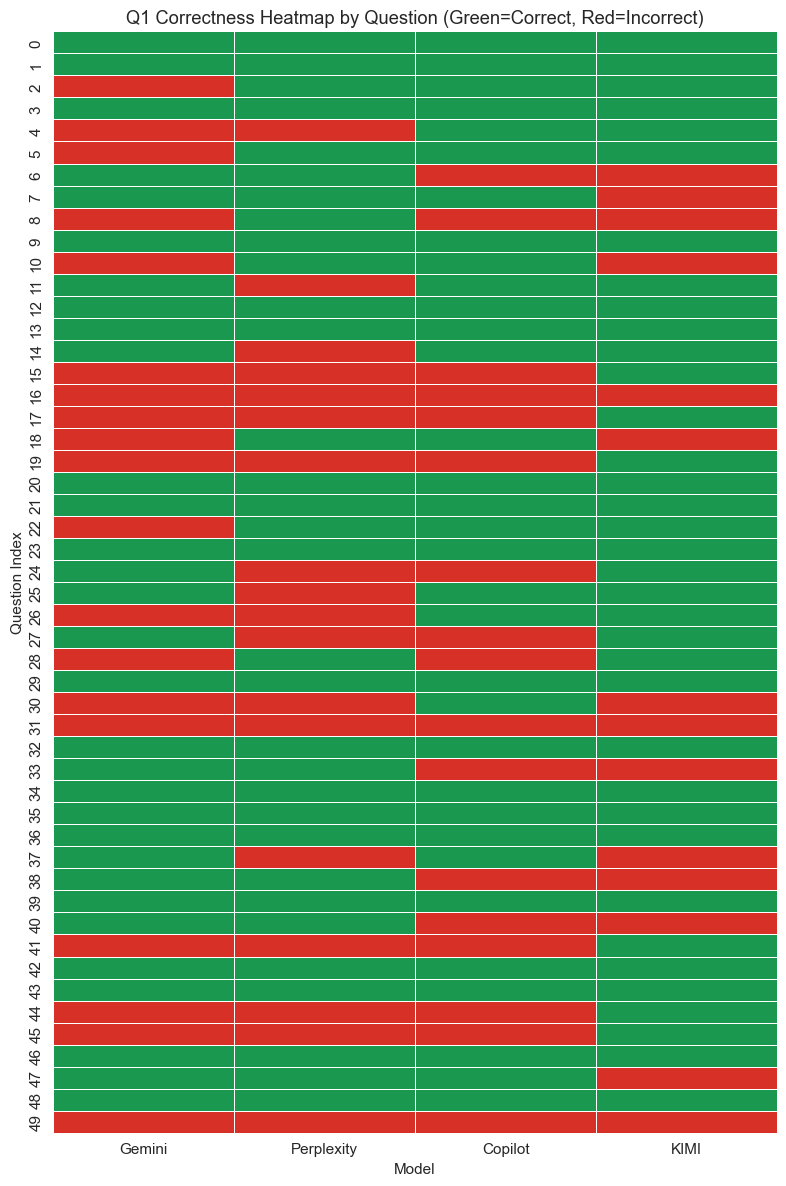

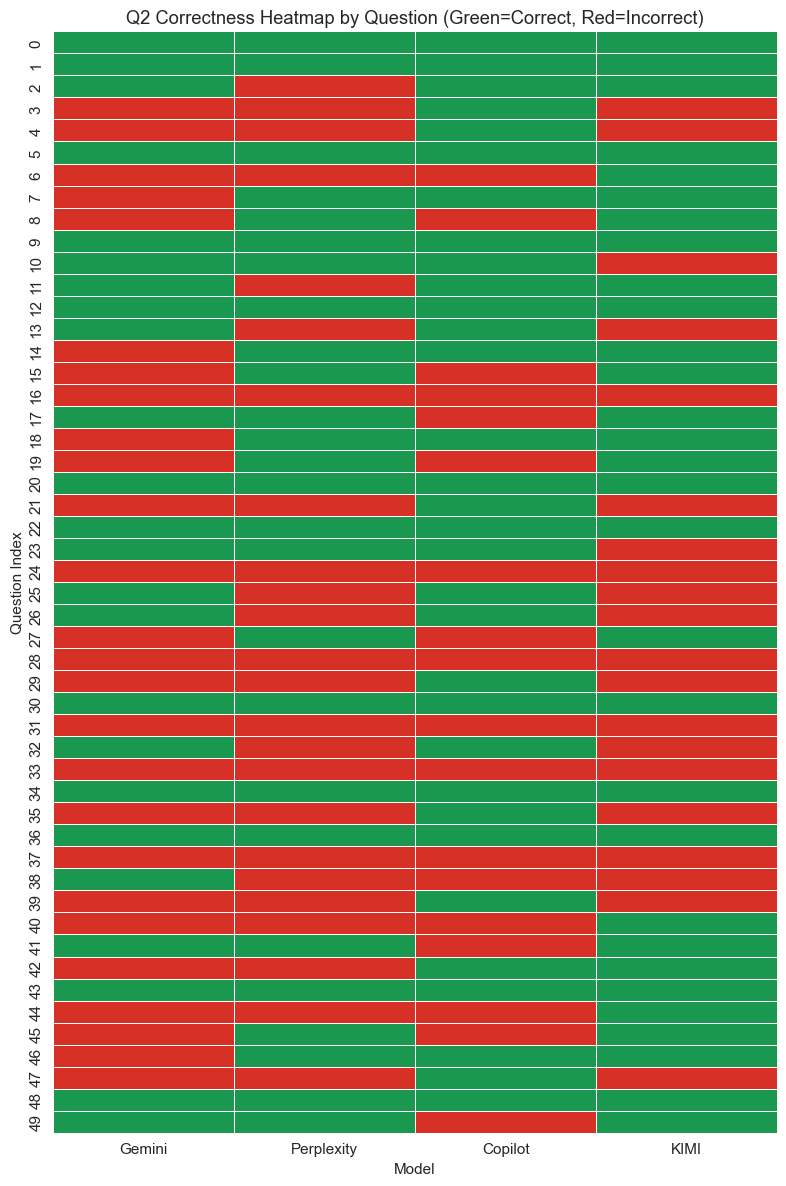

C:\Users\user\AppData\Local\Temp\ipykernel_17012\1957362317.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=q1, x="num_models_correct", palette="Blues")


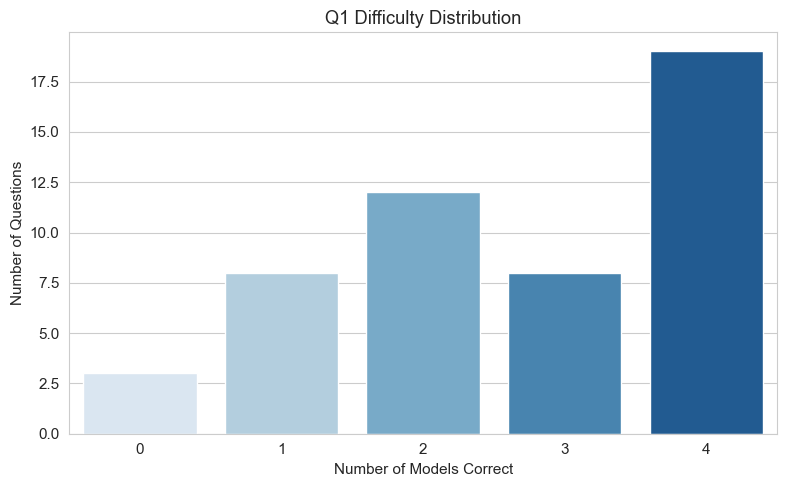

C:\Users\user\AppData\Local\Temp\ipykernel_17012\1957362317.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=q2, x="num_models_correct", palette="Purples")


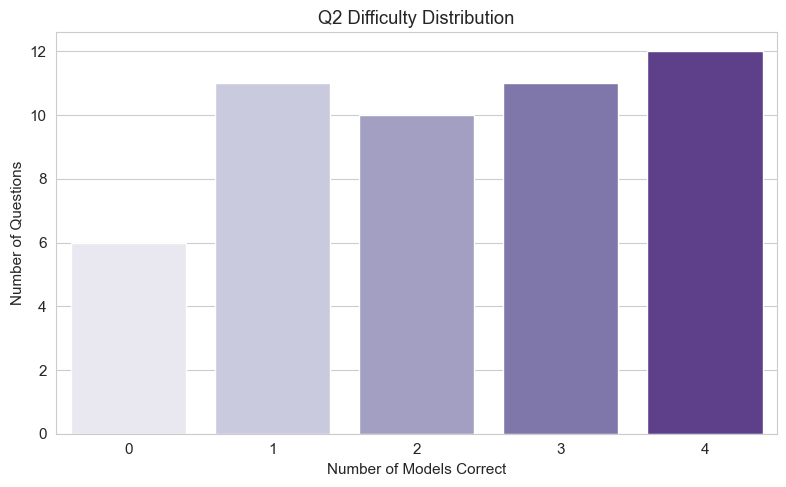

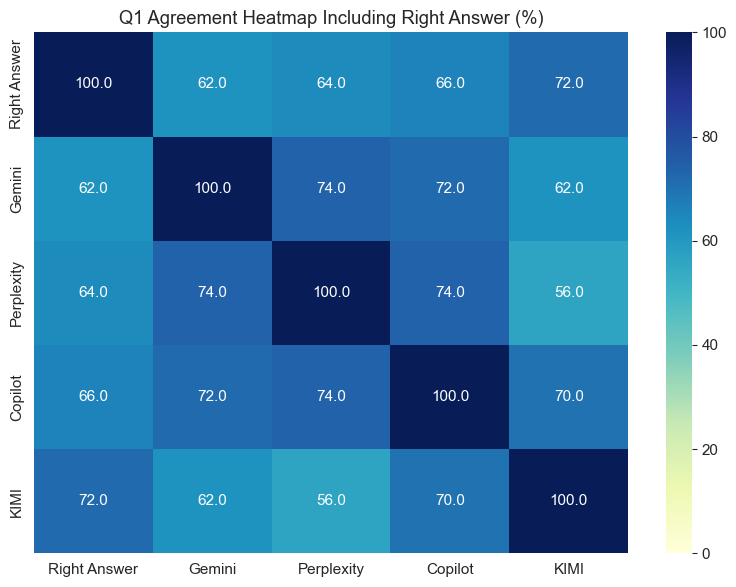

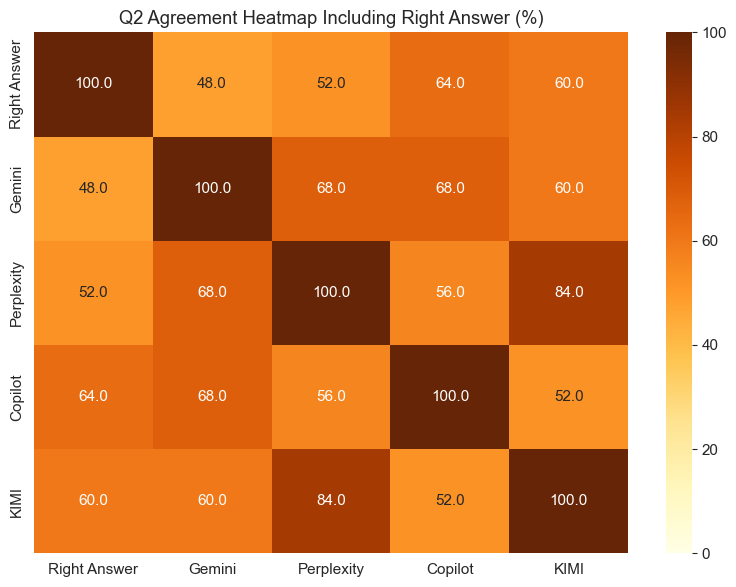

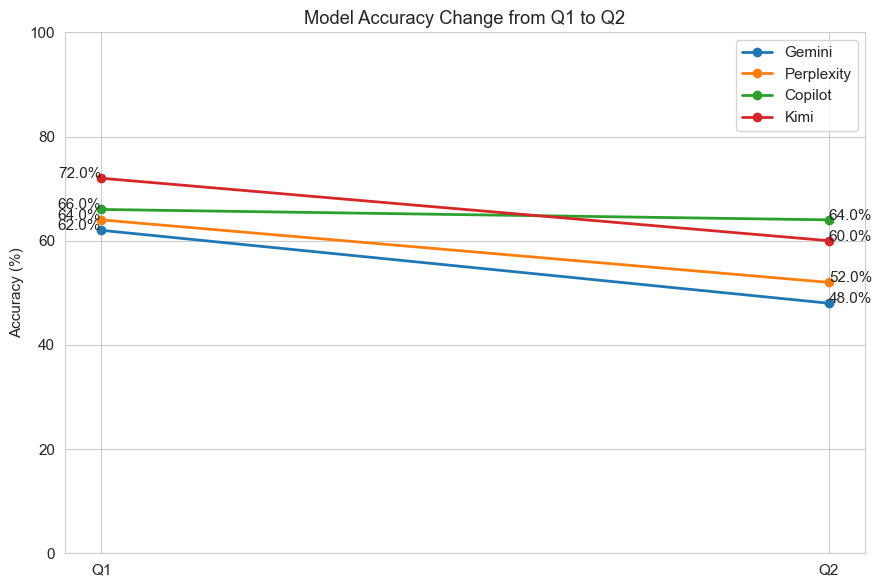

C:\Users\user\AppData\Local\Temp\ipykernel_17012\1957362317.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=diff_df, x="Model", y="Change", palette=colors)


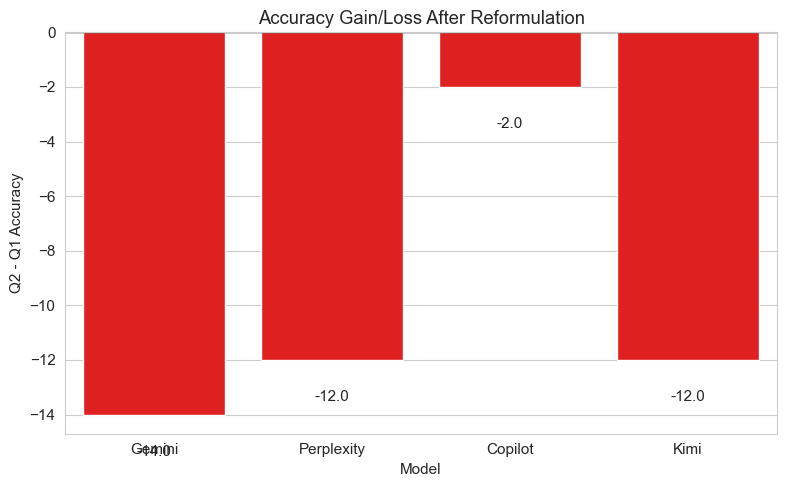

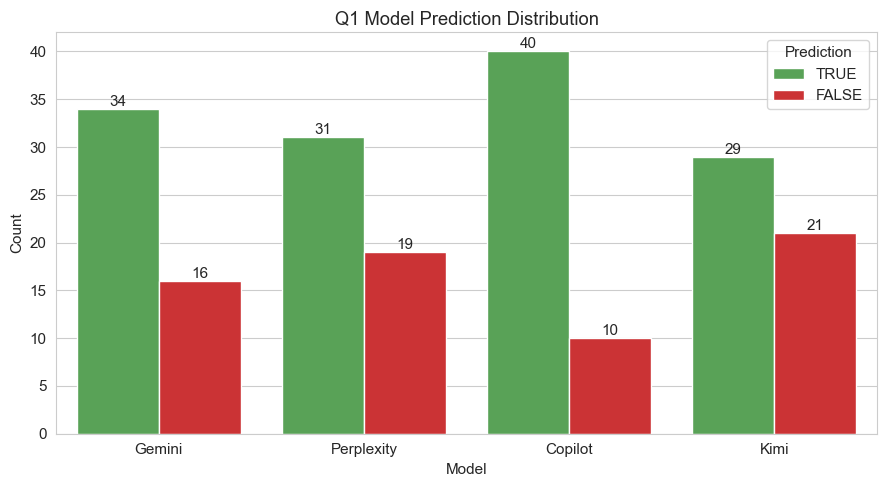

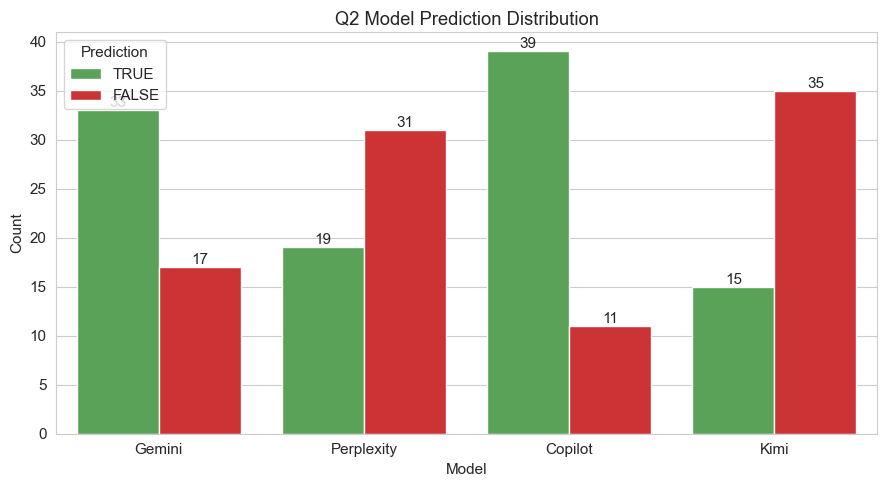

Top 10 hardest Q1 questions:


,question,answer,num_models_correct
49,IN THE WAKE OF RACIAL JUSTICE PROTESTS ACROSS ...,FAKE,0
31,SEARCH THE OFFICIAL ARCHIVES OF THE BULGARIAN ...,REAL,0
16,"DURING A MEETING WITH RUSSIA'S PRIME MINISTER,...",FAKE,0
15,ONE OF THE LARGEST MULTINATIONAL MILITARY EXER...,FAKE,1
19,A POLITICAL ANALYSIS PUBLISHED IN WESTERN EURO...,FAKE,1
30,NEWS FROM HIGHLY ACTIVE SEISMIC ZONES IS OFTEN...,REAL,1
8,IS THE PORTRAYAL OF EU LEADERS' ACTIONS AND PO...,FAKE,1
41,THE SYRIAN ARMY CONDUCTED OPERATIONS IN ALEPPO...,FAKE,1
44,DIFFERENT INVESTIGATIONS AND OFFICIALS HAVE RE...,FAKE,1
45,ZAKHAROVA LINKS SANCTIONS AGAINST RUSSIA TO IN...,FAKE,1


Top 10 hardest Q2 questions:


,question,answer,num_models_correct
24,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, LAT...",FAKE,0
31,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, TOD...",REAL,0
33,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, TAY...",REAL,0
37,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, SLA...",REAL,0
16,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, ALE...",FAKE,0
28,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, THE...",FAKE,0
6,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, NAS...",FAKE,1
29,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, TUR...",REAL,1
47,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, INV...",REAL,1
21,"TRUE OR FALSE: ACCORDING TO THE NEWS TEXT, THE...",REAL,1


All graph images saved in: C:/Users/user/Downloads/saved_graphs


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# -----------------------------
# 0. Folder to save graphs
# -----------------------------
save_dir = r"C:/Users/user/Downloads/saved_graphs"
os.makedirs(save_dir, exist_ok=True)

def save_and_show(file_name):
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, file_name), dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------
# 1. Load files
# -----------------------------
q1 = pd.read_excel("C:/Users/user/Downloads/q1.xlsx")
q2 = pd.read_excel("C:/Users/user/Downloads/q2.xlsx")

q1.columns = ["news", "question", "answer", "gemini", "perplexity", "copilot", "kimi"]
q2.columns = ["news", "answer", "question", "gemini", "perplexity", "copilot", "kimi"]

for df in [q1, q2]:
    for col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

truth_map = {"REAL": "TRUE", "FAKE": "FALSE"}
q1["expected"] = q1["answer"].map(truth_map)
q2["expected"] = q2["answer"].map(truth_map)

models = ["gemini", "perplexity", "copilot", "kimi"]

# correctness matrices
for model in models:
    q1[f"{model}_correct"] = (q1[model] == q1["expected"]).astype(int)
    q2[f"{model}_correct"] = (q2[model] == q2["expected"]).astype(int)

# -----------------------------
# 2. Correctness heatmap by question
# -----------------------------
q1_heat = q1[[f"{m}_correct" for m in models]].copy()
q1_heat.columns = ["Gemini", "Perplexity", "Copilot", "KIMI"]

plt.figure(figsize=(8, 12))
sns.heatmap(q1_heat, cmap=["#d73027", "#1a9850"], cbar=False, linewidths=0.5, linecolor="white")
plt.title("Q1 Correctness Heatmap by Question (Green=Correct, Red=Incorrect)")
plt.xlabel("Model")
plt.ylabel("Question Index")
save_and_show("q1_correctness_heatmap.png")

q2_heat = q2[[f"{m}_correct" for m in models]].copy()
q2_heat.columns = ["Gemini", "Perplexity", "Copilot", "KIMI"]

plt.figure(figsize=(8, 12))
sns.heatmap(q2_heat, cmap=["#d73027", "#1a9850"], cbar=False, linewidths=0.5, linecolor="white")
plt.title("Q2 Correctness Heatmap by Question (Green=Correct, Red=Incorrect)")
plt.xlabel("Model")
plt.ylabel("Question Index")
save_and_show("q2_correctness_heatmap.png")

# -----------------------------
# 3. Difficulty distribution
#    How many models got each question correct?
# -----------------------------
q1["num_models_correct"] = q1[[f"{m}_correct" for m in models]].sum(axis=1)
q2["num_models_correct"] = q2[[f"{m}_correct" for m in models]].sum(axis=1)

plt.figure(figsize=(8, 5))
sns.countplot(data=q1, x="num_models_correct", palette="Blues")
plt.title("Q1 Difficulty Distribution")
plt.xlabel("Number of Models Correct")
plt.ylabel("Number of Questions")
save_and_show("q1_difficulty_distribution.png")

plt.figure(figsize=(8, 5))
sns.countplot(data=q2, x="num_models_correct", palette="Purples")
plt.title("Q2 Difficulty Distribution")
plt.xlabel("Number of Models Correct")
plt.ylabel("Number of Questions")
save_and_show("q2_difficulty_distribution.png")

# -----------------------------
# 4. Agreement heatmap
#    Includes right answer now
# -----------------------------
def agreement_matrix_with_truth(df):
    compare_cols = ["expected", "gemini", "perplexity", "copilot", "kimi"]
    names = {
        "expected": "Right Answer",
        "gemini": "Gemini",
        "perplexity": "Perplexity",
        "copilot": "Copilot",
        "kimi": "KIMI"
    }

    mat = pd.DataFrame(
        index=[names[c] for c in compare_cols],
        columns=[names[c] for c in compare_cols],
        dtype=float
    )

    for c1 in compare_cols:
        for c2 in compare_cols:
            mat.loc[names[c1], names[c2]] = (df[c1] == df[c2]).mean() * 100

    return mat

q1_agree = agreement_matrix_with_truth(q1)
q2_agree = agreement_matrix_with_truth(q2)

plt.figure(figsize=(8, 6))
sns.heatmap(q1_agree, annot=True, fmt=".1f", cmap="YlGnBu", vmin=0, vmax=100)
plt.title("Q1 Agreement Heatmap Including Right Answer (%)")
save_and_show("q1_agreement_with_right_answer.png")

plt.figure(figsize=(8, 6))
sns.heatmap(q2_agree, annot=True, fmt=".1f", cmap="YlOrBr", vmin=0, vmax=100)
plt.title("Q2 Agreement Heatmap Including Right Answer (%)")
save_and_show("q2_agreement_with_right_answer.png")

# -----------------------------
# 5. Q1 vs Q2 slope chart
# -----------------------------
acc_q1 = {m.capitalize(): q1[f"{m}_correct"].mean() * 100 for m in models}
acc_q2 = {m.capitalize(): q2[f"{m}_correct"].mean() * 100 for m in models}

plt.figure(figsize=(9, 6))
for model in acc_q1.keys():
    plt.plot(["Q1", "Q2"], [acc_q1[model], acc_q2[model]], marker="o", linewidth=2, label=model)

for model in acc_q1.keys():
    plt.text("Q1", acc_q1[model], f"{acc_q1[model]:.1f}%", ha="right")
    plt.text("Q2", acc_q2[model], f"{acc_q2[model]:.1f}%", ha="left")

plt.title("Model Accuracy Change from Q1 to Q2")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.legend()
save_and_show("q1_q2_accuracy_change_slope.png")

# -----------------------------
# 6. Improvement / decline bar chart
# -----------------------------
diff_df = pd.DataFrame({
    "Model": list(acc_q1.keys()),
    "Q1 Accuracy": list(acc_q1.values()),
    "Q2 Accuracy": list(acc_q2.values())
})
diff_df["Change"] = diff_df["Q2 Accuracy"] - diff_df["Q1 Accuracy"]

plt.figure(figsize=(8, 5))
colors = ["green" if x >= 0 else "red" for x in diff_df["Change"]]
ax = sns.barplot(data=diff_df, x="Model", y="Change", palette=colors)
plt.axhline(0, color="black", linewidth=1)
plt.title("Accuracy Gain/Loss After Reformulation")
plt.ylabel("Q2 - Q1 Accuracy")
for i, v in enumerate(diff_df["Change"]):
    ax.text(i, v + (0.5 if v >= 0 else -1.5), f"{v:.1f}", ha="center")
save_and_show("q1_q2_gain_loss.png")

# -----------------------------
# 7. Real vs Fake answer balance by model
#    What each model tends to predict
# -----------------------------
def prediction_distribution(df, title, palette, file_name):
    pred_rows = []
    for model in models:
        counts = df[model].value_counts(dropna=False)
        for ans in ["TRUE", "FALSE"]:
            pred_rows.append({
                "Model": model.capitalize(),
                "Prediction": ans,
                "Count": counts.get(ans, 0)
            })
    pred_df = pd.DataFrame(pred_rows)

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(data=pred_df, x="Model", y="Count", hue="Prediction", palette=palette)
    plt.title(title)
    for container in ax.containers:
        ax.bar_label(container)
    save_and_show(file_name)

prediction_distribution(q1, "Q1 Model Prediction Distribution", ["#4daf4a", "#e41a1c"], "q1_prediction_distribution.png")
prediction_distribution(q2, "Q2 Model Prediction Distribution", ["#4daf4a", "#e41a1c"], "q2_prediction_distribution.png")

# -----------------------------
# 8. Hardest questions
#    Questions missed by most models
# -----------------------------
hard_q1 = q1[["question", "answer", "num_models_correct"]].sort_values("num_models_correct").head(10)
hard_q2 = q2[["question", "answer", "num_models_correct"]].sort_values("num_models_correct").head(10)

print("Top 10 hardest Q1 questions:")
display(hard_q1)

print("Top 10 hardest Q2 questions:")
display(hard_q2)

print(f"All graph images saved in: {save_dir}")

In [5]:
import pandas as pd

# Load files
q1 = pd.read_excel("C:/Users/user/Downloads/q1.xlsx")
q2 = pd.read_excel("C:/Users/user/Downloads/q2.xlsx")

q1.columns = ["news", "question", "answer", "gemini", "perplexity", "copilot", "kimi"]
q2.columns = ["news", "answer", "question", "gemini", "perplexity", "copilot", "kimi"]

for df in [q1, q2]:
    for col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

truth_map = {"REAL": "TRUE", "FAKE": "FALSE"}
models = ["gemini", "perplexity", "copilot", "kimi"]

# Expected answer
q1["expected"] = q1["answer"].map(truth_map)
q2["expected"] = q2["answer"].map(truth_map)

# Right/wrong columns for Q1
for model in models:
    q1[f"{model}_right"] = q1[model] == q1["expected"]
    q1[f"{model}_result"] = q1[f"{model}_right"].map({True: "RIGHT", False: "WRONG"})

# Right/wrong columns for Q2
for model in models:
    q2[f"{model}_right"] = q2[model] == q2["expected"]
    q2[f"{model}_result"] = q2[f"{model}_right"].map({True: "RIGHT", False: "WRONG"})

# Show just the useful result table
q1_results = q1[["news", "answer"] + [f"{m}_result" for m in models]]
q2_results = q2[["news", "answer"] + [f"{m}_result" for m in models]]

print("Q1 results:")
display(q1_results.head(10))

print("Q2 results:")
display(q2_results.head(10))

# Save output tables
q1_results.to_csv("q1_right_wrong_results.csv", index=False)
q2_results.to_csv("q2_right_wrong_results.csv", index=False)

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Q1 results:


,news,answer,gemini_result,perplexity_result,copilot_result,kimi_result
0,"PAJU, SOUTH KOREA: US MILITARY ARMORED VEHICLE...",REAL,RIGHT,RIGHT,RIGHT,RIGHT
1,RON DESANTIS IS ACCUSED OF HAVING DECEIVED VEN...,REAL,RIGHT,RIGHT,RIGHT,RIGHT
2,WITH THE BOMBARDMENTS AIMED AT ENERGY INFRASTR...,REAL,WRONG,RIGHT,RIGHT,RIGHT
3,GOVERNMENT AGREES TO WORK MORE CLOSELY WITH TH...,REAL,RIGHT,RIGHT,RIGHT,RIGHT
4,SURVEY DATA SHOWS THAT ALMOST HALF OF LITHUANI...,REAL,WRONG,WRONG,RIGHT,RIGHT
5,SEVEN MONTHS AFTER THREE OF RUSSIA'S FOUR NORD...,FAKE,WRONG,RIGHT,RIGHT,RIGHT
6,PUBLISH DATE: 09.12.2020 | 08:23 GMT | LAST UP...,FAKE,RIGHT,RIGHT,WRONG,WRONG
7,DATA ON THE PRODUCTION AND STORAGE OF THE NERV...,FAKE,RIGHT,RIGHT,RIGHT,WRONG
8,IT IS NECESSARY THAT ALL MEMBER STATES ADOPT T...,FAKE,WRONG,RIGHT,WRONG,WRONG
9,DEMOCRATIC PRESIDENTIAL CANDIDATE HILLARY CLIN...,FAKE,RIGHT,RIGHT,RIGHT,RIGHT


Q2 results:


,news,answer,gemini_result,perplexity_result,copilot_result,kimi_result
0,"PAJU, SOUTH KOREA: US MILITARY ARMORED VEHICLE...",REAL,RIGHT,RIGHT,RIGHT,RIGHT
1,RON DESANTIS IS ACCUSED OF HAVING DECEIVED VEN...,REAL,RIGHT,RIGHT,RIGHT,RIGHT
2,WITH THE BOMBARDMENTS AIMED AT ENERGY INFRASTR...,REAL,RIGHT,WRONG,RIGHT,RIGHT
3,GOVERNMENT AGREES TO WORK MORE CLOSELY WITH TH...,REAL,WRONG,WRONG,RIGHT,WRONG
4,SURVEY DATA SHOWS THAT ALMOST HALF OF LITHUANI...,REAL,WRONG,WRONG,RIGHT,WRONG
5,SEVEN MONTHS AFTER THREE OF RUSSIA'S FOUR NORD...,FAKE,RIGHT,RIGHT,RIGHT,RIGHT
6,PUBLISH DATE: 09.12.2020 | 08:23 GMT | LAST UP...,FAKE,WRONG,WRONG,WRONG,RIGHT
7,DATA ON THE PRODUCTION AND STORAGE OF THE NERV...,FAKE,WRONG,RIGHT,RIGHT,RIGHT
8,IT IS NECESSARY THAT ALL MEMBER STATES ADOPT T...,FAKE,WRONG,RIGHT,WRONG,RIGHT
9,DEMOCRATIC PRESIDENTIAL CANDIDATE HILLARY CLIN...,FAKE,RIGHT,RIGHT,RIGHT,RIGHT


OSError: [Errno 28] No space left on device